# Evaluate Model Bundle

Notebook này chấm một model trong `model_bundles/` trên một file JSON có format giống `valid.json`. Chỉnh hai biến hardcode `MODEL_CODE` và `VALID_JSON_PATH`, sau đó run all.

In [5]:
import json
import math
import re
import time
from pathlib import Path

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_CODE = "duong-finetuned"
VALID_JSON_PATH = Path("dataset-math/valid.json")

SAFE_EOS_ID = 50256
PROMPT_TEMPLATE = (
    "Hãy giải bài toán. Chỉ viết kết quả số cuối cùng, không viết lời giải.\n"
    "Dạng bài: {sample_type}\n"
    "Câu hỏi: {q}\n"
    "Đáp án là: "
)
MAX_NEW_TOKENS = 128
MAX_LENGTH = 512
BATCH_SIZE = 32

PROJECT_ROOT = Path.cwd().resolve()
BUNDLE_DIR = PROJECT_ROOT / "model_bundles" / MODEL_CODE
MODEL_DIR = Path("experiments_12h/exp_15_gsm_oversample_epoch5/artifacts/model")
RESULT_DIR = PROJECT_ROOT / "results" / f"{MODEL_CODE}_{VALID_JSON_PATH.stem}"
OUTPUT_PATH = RESULT_DIR / "output.json"

if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục model: {MODEL_DIR}")
if not VALID_JSON_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file validation: {VALID_JSON_PATH}")
if not torch.cuda.is_available():
    raise RuntimeError("Notebook này được cấu hình infer bằng GPU nhưng torch.cuda.is_available() = False.")

DEVICE = "cuda"
DTYPE = torch.float16

print("MODEL_CODE:", MODEL_CODE)
print("VALID_JSON_PATH:", VALID_JSON_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("CUDA device:", torch.cuda.get_device_name(0))

MODEL_CODE: duong-finetuned
VALID_JSON_PATH: dataset-math/valid.json
OUTPUT_PATH: /mnt/c/Users/Admin/Desktop/UET/DeepLearning/new_btl_DL/results/duong-finetuned_valid/output.json
CUDA device: NVIDIA GeForce RTX 5060


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
tokenizer.pad_token_id = SAFE_EOS_ID
tokenizer.eos_token_id = SAFE_EOS_ID
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    dtype=DTYPE,
).to(DEVICE)
model.config.pad_token_id = SAFE_EOS_ID
model.config.eos_token_id = SAFE_EOS_ID
model.eval()

VOCAB_SIZE = model.transformer.wte.num_embeddings
print(f"Loaded model from {MODEL_DIR} on {DEVICE} with dtype={DTYPE}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 279.40it/s]

Loaded model from experiments_12h/exp_15_gsm_oversample_epoch5/artifacts/model on cuda with dtype=torch.float16


In [7]:
BOXED_RE = re.compile(r"\\boxed\s*\{([^{}]+)\}")
ANSWER_RE = re.compile(
    r"(?:Đáp\s*án\s*là|Câu\s*trả\s*lời\s*là|The\s+answer\s+is|####)\s*[:：]?\s*([^\n]+)",
    re.IGNORECASE,
)
LATEX_FRAC_RE = re.compile(r"-?\\frac\s*\{\s*(-?\d+(?:[.,]\d+)?)\s*\}\s*\{\s*(-?\d+(?:[.,]\d+)?)\s*\}")
PLAIN_FRAC_RE = re.compile(r"(?<![\w.])-?\d+(?:[.,]\d+)?\s*/\s*-?\d+(?:[.,]\d+)?(?![\w.])")
NUMBER_RE = re.compile(r"(?<![\w.])-?\d+(?:[.,]\d+)?(?![\w.])")

def normalize_number_text(text):
    return str(text).strip().replace("−", "-").replace(",", ".")

def number_to_float(text):
    if text is None:
        return None
    value = normalize_number_text(text)
    latex_match = LATEX_FRAC_RE.fullmatch(value)
    if latex_match:
        numerator = float(normalize_number_text(latex_match.group(1)))
        denominator = float(normalize_number_text(latex_match.group(2)))
        return numerator / denominator if denominator != 0 else None
    if "/" in value:
        numerator, denominator = [part.strip() for part in value.split("/", 1)]
        denominator = float(normalize_number_text(denominator))
        return float(normalize_number_text(numerator)) / denominator if denominator != 0 else None
    try:
        return float(value)
    except ValueError:
        return None

def number_tokens(text):
    if not text:
        return []
    tokens = []
    for match in LATEX_FRAC_RE.finditer(text):
        tokens.append((match.start(), match.group(0)))
    scrubbed = LATEX_FRAC_RE.sub(" ", text)
    for match in PLAIN_FRAC_RE.finditer(scrubbed):
        tokens.append((match.start(), match.group(0)))
    scrubbed = PLAIN_FRAC_RE.sub(" ", scrubbed)
    for match in NUMBER_RE.finditer(scrubbed):
        tokens.append((match.start(), match.group(0)))
    return [token for _, token in sorted(tokens, key=lambda item: item[0])]

def parse_answer(text):
    if not text:
        return None
    boxed = BOXED_RE.findall(text)
    if boxed:
        tokens = number_tokens(boxed[-1])
        if tokens:
            return tokens[-1]
    answer_matches = ANSWER_RE.findall(text)
    for candidate in reversed(answer_matches):
        tokens = number_tokens(candidate)
        if tokens:
            return tokens[-1]
    tokens = number_tokens(text)
    return tokens[-1] if tokens else None

def score_prediction(gold_answer, model_answer):
    gold_num = number_to_float(gold_answer)
    pred_num = number_to_float(model_answer)
    if gold_num is None or pred_num is None:
        return None, 0
    relative_error = abs(pred_num - gold_num) / max(1.0, abs(gold_num))
    if relative_error <= 0.01:
        return relative_error, 10
    if relative_error <= 0.10:
        return relative_error, 5
    if relative_error <= 0.50:
        return relative_error, 1
    return relative_error, 0

In [11]:
records = json.loads(VALID_JSON_PATH.read_text(encoding="utf-8"))
print(f"Loaded {len(records)} validation records")

def build_prompt(record):
    return PROMPT_TEMPLATE.format(
        q=record["query_vi"].strip(),
        sample_type=str(record.get("type") or "unknown").strip(),
    )

def infer_batch(batch):
    prompts = [build_prompt(record) for record in batch]
    encoded = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(DEVICE)
    input_ids = encoded["input_ids"].clamp(max=VOCAB_SIZE - 1)
    with torch.inference_mode():
        generated = model.generate(
            input_ids=input_ids,
            attention_mask=encoded.get("attention_mask"),
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            pad_token_id=SAFE_EOS_ID,
            eos_token_id=SAFE_EOS_ID,
        )
    responses = tokenizer.batch_decode(
        generated[:, input_ids.shape[1]:],
        skip_special_tokens=True,
    )
    return prompts, responses

def bucket_counts(rows):
    return {str(bucket): sum(1 for row in rows if row["score"] == bucket) for bucket in (10, 5, 1, 0)}

def model_answer_null_count(rows):
    return sum(row["model_answer"] is None for row in rows)

def build_summary(rows, elapsed_seconds):
    n = len(rows)
    raw_score = sum(row["score"] for row in rows)
    types = sorted({row.get("type") or "unknown" for row in rows})
    by_type = {}
    for sample_type in types:
        type_rows = [row for row in rows if (row.get("type") or "unknown") == sample_type]
        type_raw_score = sum(row["score"] for row in type_rows)
        type_n = len(type_rows)
        by_type[sample_type] = {
            "n": type_n,
            "raw_score": type_raw_score,
            "max_raw_score": 10 * type_n,
            "score_10": type_raw_score / type_n if type_n else 0.0,
            "score_pct": type_raw_score / (10 * type_n) if type_n else 0.0,
            "bucket_counts": bucket_counts(type_rows),
            "model_answer_null_count": model_answer_null_count(type_rows),
        }
    return {
        "n": n,
        "raw_score": raw_score,
        "max_raw_score": 10 * n,
        "score_10": raw_score / n if n else 0.0,
        "score_pct": raw_score / (10 * n) if n else 0.0,
        "bucket_counts": bucket_counts(rows),
        "by_type": by_type,
        "extractable": sum(row["model_answer"] is not None for row in rows),
        "model_answer_null_count": model_answer_null_count(rows),
        "elapsed_seconds": elapsed_seconds,
        "output_path": str(OUTPUT_PATH),
    }

started = time.time()
output_rows = []

for start in range(0, len(records), BATCH_SIZE):
    batch = records[start:start + BATCH_SIZE]
    prompts, responses = infer_batch(batch)
    for record, prompt, model_response in zip(batch, prompts, responses):
        gold_answer = parse_answer(record.get("model_output") or record.get("response_en") or "")
        model_answer = parse_answer(model_response)
        relative_error, score = score_prediction(gold_answer, model_answer)
        output_rows.append({
            **record,
            "prompt": prompt,
            "gold_answer": gold_answer,
            "model_response": model_response,
            "model_answer": model_answer,
            "relative_error": relative_error,
            "score": score,
        })
    print(f"Done {len(output_rows)}/{len(records)}", flush=True)

elapsed = time.time() - started
summary = build_summary(output_rows, elapsed)
output_payload = {
    "summary": summary,
    "rows": output_rows,
}

RESULT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(output_payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(summary, ensure_ascii=False, indent=2))

Loaded 1000 validation records
Done 32/1000
Done 64/1000
Done 96/1000
Done 128/1000
Done 160/1000
Done 192/1000
Done 224/1000
Done 256/1000
Done 288/1000
Done 320/1000
Done 352/1000
Done 384/1000
Done 416/1000
Done 448/1000
Done 480/1000
Done 512/1000
Done 544/1000
Done 576/1000
Done 608/1000
Done 640/1000
Done 672/1000
Done 704/1000
Done 736/1000
Done 768/1000
Done 800/1000
Done 832/1000
Done 864/1000
Done 896/1000
Done 928/1000
Done 960/1000
Done 992/1000
Done 1000/1000
{
  "n": 1000,
  "raw_score": 5997,
  "max_raw_score": 10000,
  "score_10": 5.997,
  "score_pct": 0.5997,
  "bucket_counts": {
    "10": 574,
    "5": 23,
    "1": 142,
    "0": 261
  },
  "by_type": {
    "GSM_AnsAug": {
      "n": 209,
      "raw_score": 1939,
      "max_raw_score": 2090,
      "score_10": 9.277511961722489,
      "score_pct": 0.9277511961722488,
      "bucket_counts": {
        "10": 192,
        "5": 3,
        "1": 4,
        "0": 10
      },
      "model_answer_null_count": 1
    },
    "GSM_FOB

Model/valid: duong-finetuned_valid
Output path: /mnt/c/Users/Admin/Desktop/UET/DeepLearning/new_btl_DL/results/duong-finetuned_valid/output.json
Rows: 1000


Field,Value
n,1000
raw_score,5997
max_raw_score,10000
score_10,5.997
score_pct,0.5997
bucket_counts.10,574
bucket_counts.5,23
bucket_counts.1,142
bucket_counts.0,261
by_type.GSM_AnsAug.n,209


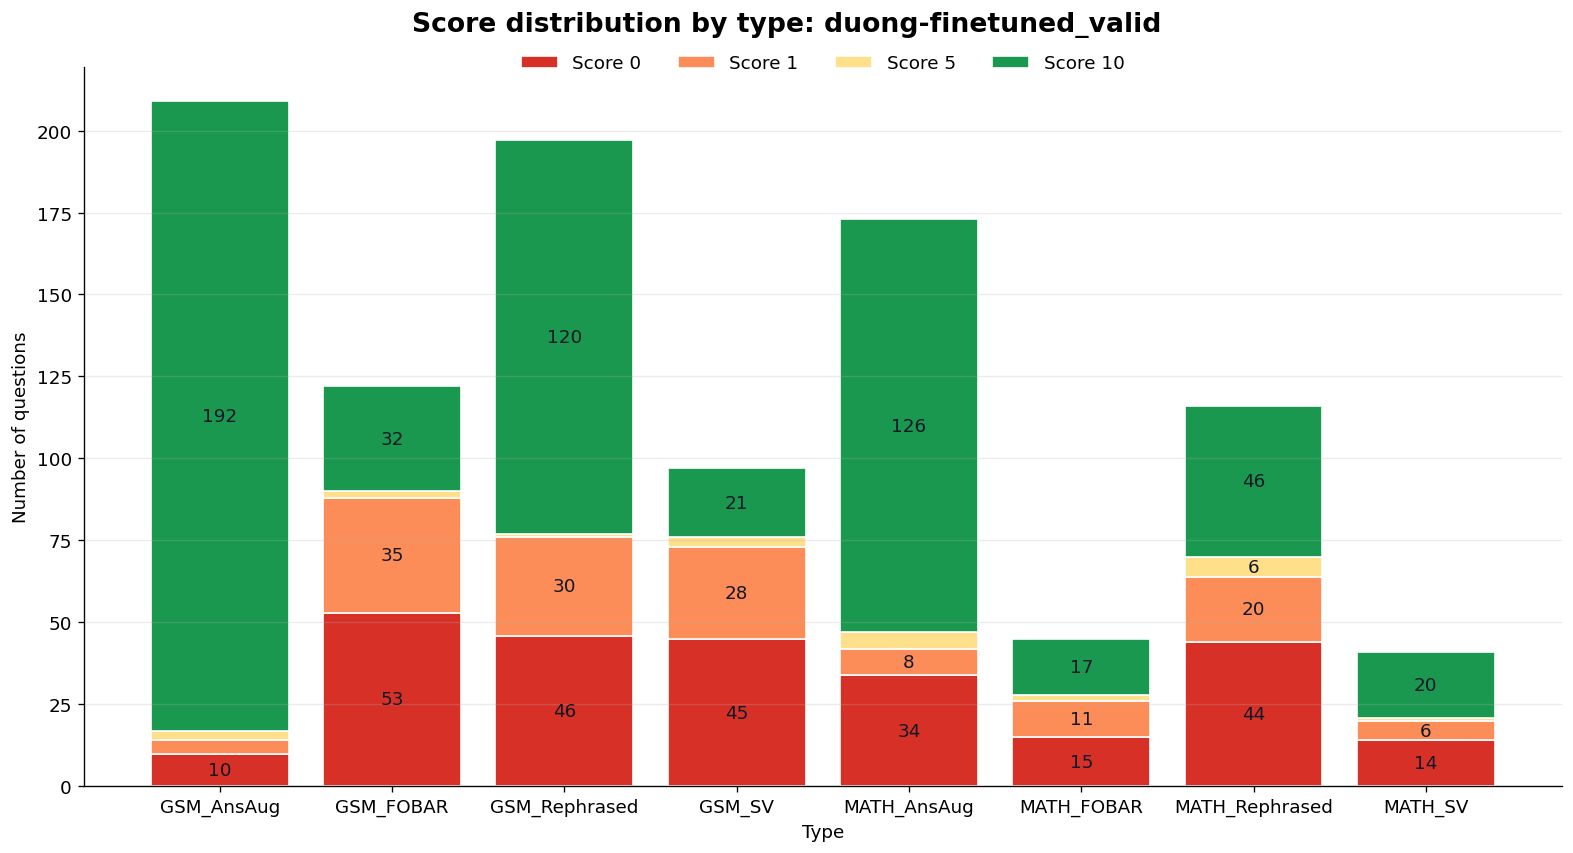

    'data': [{'customdata': [['Bà Dunbar đang cắm hoa cho đám cưới của cháu gái
…

In [12]:
from pathlib import Path
from collections import Counter, defaultdict
from html import escape
import json

from IPython.display import HTML, display
import ipywidgets as widgets
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import plotly.graph_objects as go

analysis_output_path = Path(globals().get("OUTPUT_PATH", Path("results/gpt2-vietnamese-math-finetuned_valid_co/output.json")))
payload = json.loads(analysis_output_path.read_text(encoding="utf-8"))

if isinstance(payload, list):
    output_rows_for_stats = payload
    output_summary_for_stats = {}
else:
    output_summary_for_stats = payload.get("summary", {})
    output_rows_for_stats = payload.get("rows", [])

model_valid_pair = analysis_output_path.parent.name
print(f"Model/valid: {model_valid_pair}")
print(f"Output path: {analysis_output_path}")
print(f"Rows: {len(output_rows_for_stats)}")


def flatten_summary(value, prefix=""):
    if isinstance(value, dict):
        for key, child in value.items():
            child_prefix = f"{prefix}.{key}" if prefix else str(key)
            yield from flatten_summary(child, child_prefix)
    else:
        yield prefix, value


def render_summary_table(summary):
    rows = list(flatten_summary(summary))
    if not rows:
        return "<p>No summary found.</p>"
    body = "".join(
        "<tr>"
        f"<td>{escape(str(field))}</td>"
        f"<td>{escape(json.dumps(value, ensure_ascii=False) if isinstance(value, (list, dict)) else str(value))}</td>"
        "</tr>"
        for field, value in rows
    )
    return f"""
    <style>
      .summary-table {{ border-collapse: collapse; margin: 8px 0 18px; font-family: Arial, sans-serif; font-size: 13px; }}
      .summary-table th, .summary-table td {{ border: 1px solid #d1d5db; padding: 7px 10px; text-align: left; }}
      .summary-table th {{ background: #f3f4f6; font-weight: 700; }}
      .summary-table td:first-child {{ font-family: Consolas, monospace; color: #374151; }}
    </style>
    <h3 style="font-family: Arial, sans-serif; margin-bottom: 6px;">Output summary</h3>
    <table class="summary-table">
      <thead><tr><th>Field</th><th>Value</th></tr></thead>
      <tbody>{body}</tbody>
    </table>
    """


def value_text(value):
    if value is None:
        return "None"
    if isinstance(value, float):
        return f"{value:.8g}"
    return str(value)


def paragraph_text(value):
    return escape(value_text(value)).replace("\n", "<br>")


def render_question_detail(row=None):
    if row is None:
        return """
        <div style="border:1px solid #d1d5db;border-radius:8px;padding:14px 16px;font-family:Arial,sans-serif;background:#f9fafb;">
          <b>Chi tiết câu hỏi</b><br>
          Click vào một điểm trên biểu đồ để xem câu hỏi, đáp án chuẩn và response của model.
        </div>
        """
    fields = [
        ("ID", row.get("id")),
        ("Type", row.get("type")),
        ("Prompt gửi model", row.get("prompt")),
        ("Câu hỏi", row.get("query_vi") or row.get("original_question_vi") or row.get("query_en")),
        ("Response chuẩn", row.get("model_output") or row.get("response_en")),
        ("Response của model", row.get("model_response")),
        ("Gold answer", row.get("gold_answer")),
        ("Model answer", row.get("model_answer")),
        ("Relative error", row.get("relative_error")),
        ("Điểm", row.get("score")),
    ]
    body = "".join(
        "<tr>"
        f"<th>{escape(label)}</th>"
        f"<td>{paragraph_text(value)}</td>"
        "</tr>"
        for label, value in fields
    )
    score = row.get("score")
    score_color = score_colors.get(score, "#2563eb")
    return f"""
    <div style="border:1px solid #d1d5db;border-left:6px solid {score_color};border-radius:8px;padding:14px 16px;font-family:Arial,sans-serif;background:#ffffff;box-shadow:0 1px 3px rgba(0,0,0,0.08);">
      <div style="font-size:16px;font-weight:700;margin-bottom:10px;">Chi tiết câu hỏi #{escape(value_text(row.get('id')))}</div>
      <table style="border-collapse:collapse;width:100%;font-size:13px;line-height:1.45;">
        <tbody>{body}</tbody>
      </table>
    </div>
    <style>
      table th {{ width: 170px; text-align:left; vertical-align:top; padding:6px 10px 6px 0; color:#374151; }}
      table td {{ vertical-align:top; padding:6px 0; white-space:normal; }}
    </style>
    """


display(HTML(render_summary_table(output_summary_for_stats)))

score_order = [0, 1, 5, 10]
score_colors = {0: "#d73027", 1: "#fc8d59", 5: "#fee08b", 10: "#1a9850"}
rows_by_type = defaultdict(list)
for row in output_rows_for_stats:
    rows_by_type[row.get("type") or "unknown"].append(row)

types = sorted(rows_by_type)
type_score_counts = {
    sample_type: Counter(row.get("score") for row in type_rows)
    for sample_type, type_rows in rows_by_type.items()
}

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
    "font.size": 11,
})

fig_type, ax_type = plt.subplots(figsize=(13, 7), dpi=120, constrained_layout=True)
fig_type.suptitle(f"Score distribution by type: {model_valid_pair}", fontsize=16, fontweight="bold")

bottom = [0] * len(types)
max_total = max((len(rows_by_type[sample_type]) for sample_type in types), default=1)
for score in score_order:
    values = [type_score_counts[sample_type].get(score, 0) for sample_type in types]
    bars = ax_type.bar(
        types,
        values,
        bottom=bottom,
        label=f"Score {score}",
        color=score_colors[score],
        edgecolor="white",
        linewidth=1.0,
    )
    for bar, value, base in zip(bars, values, bottom):
        if value and value / max_total >= 0.025:
            ax_type.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                str(value),
                ha="center",
                va="center",
                fontsize=11,
                color="#111827",
            )
    bottom = [current + value for current, value in zip(bottom, values)]

ax_type.set_xlabel("Type")
ax_type.set_ylabel("Number of questions")
ax_type.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_type.grid(axis="y", alpha=0.25)
ax_type.legend(frameon=False, ncol=len(score_order), loc="upper center", bbox_to_anchor=(0.5, 1.04))
plt.show()

sorted_rows = sorted(output_rows_for_stats, key=lambda row: row.get("id", 0))
fig_id = go.FigureWidget()
trace_rows_by_score = []

for score in score_order:
    trace_rows = [row for row in sorted_rows if row.get("score") == score]
    trace_rows_by_score.append(trace_rows)
    fig_id.add_trace(go.Scatter(
        x=[row.get("id") for row in trace_rows],
        y=[row.get("score") for row in trace_rows],
        mode="markers",
        name=f"Score {score}",
        marker={"size": 8, "color": score_colors[score], "opacity": 0.72},
        customdata=[
            [
                row.get("query_vi") or row.get("original_question_vi") or row.get("query_en"),
                row.get("model_answer"),
                row.get("relative_error"),
            ]
            for row in trace_rows
        ],
        hovertemplate=(
            "<b>ID %{x}</b><br>"
            "Score: %{y}<br>"
            "Question: %{customdata[0]}<br>"
            "Model answer: %{customdata[1]}<br>"
            "Relative error: %{customdata[2]}"
            "<extra></extra>"
        ),
    ))

fig_id.add_trace(go.Scatter(
    x=[],
    y=[],
    mode="markers",
    name="Selected",
    marker={"size": 18, "color": "rgba(0,0,0,0)", "line": {"width": 3, "color": "#111827"}},
    hoverinfo="skip",
    showlegend=False,
))
selected_trace_index = len(fig_id.data) - 1

detail_panel = widgets.HTML(value=render_question_detail(), layout=widgets.Layout(width="100%"))


def make_click_handler(trace_rows):
    def handle_click(trace, points, selector):
        if not points.point_inds:
            return
        point_index = points.point_inds[0]
        selected_row = trace_rows[point_index]
        detail_panel.value = render_question_detail(selected_row)
        with fig_id.batch_update():
            fig_id.data[selected_trace_index].x = [selected_row.get("id")]
            fig_id.data[selected_trace_index].y = [selected_row.get("score")]
    return handle_click


for trace, trace_rows in zip(fig_id.data[:-1], trace_rows_by_score):
    trace.on_click(make_click_handler(trace_rows))

fig_id.update_layout(
    title={"text": f"Interactive score distribution by question id: {model_valid_pair}", "x": 0.5},
    template="plotly_white",
    height=650,
    margin={"l": 70, "r": 30, "t": 90, "b": 70},
    clickmode="event+select",
    hovermode="closest",
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "center", "x": 0.5},
    xaxis={"title": "Question id", "showgrid": True, "gridcolor": "#eef2f7"},
    yaxis={"title": "Score", "tickmode": "array", "tickvals": score_order, "range": [-0.75, 10.75], "showgrid": True, "gridcolor": "#e5e7eb"},
)

display(widgets.VBox([fig_id, detail_panel], layout=widgets.Layout(width="100%", gap="12px")))